# Worksheet 9 -- Dynamical Models with NNs

## 1 Analysing the dynamic of the Lorenz system

In [41]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchdiffeq import odeint

In [42]:
# Constants
sigma = 10
rho = 28
beta = 8/3
epsilon = 1e-9

In [43]:
def rhs(t, x_hat):
    x, y, z = x_hat
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = (x * y) - (beta * z)
    return dx, dy, dz

In [44]:
x_0_1 = [5., 5., 5.]
x_0_2 = [5., 5., 5. + epsilon]
t_eval = np.linspace(0, 40, 10000)

In [45]:
bunch_1 = solve_ivp(rhs, (0, 40), x_0_1, t_eval=t_eval, rtol=1e-10, atol=1e-12)
bunch_2 = solve_ivp(rhs, (0, 40), x_0_2, t_eval=t_eval, rtol=1e-10, atol=1e-12)

In [46]:
traj_1, traj_2 = bunch_1.y, bunch_2.y

Text(0, 0.5, 'separation d(t)')

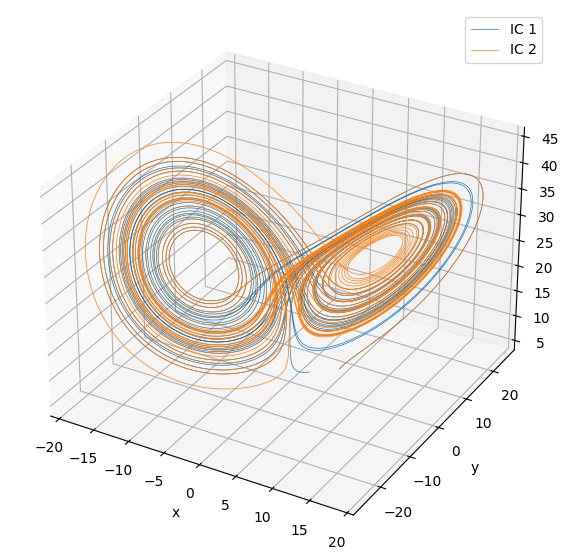

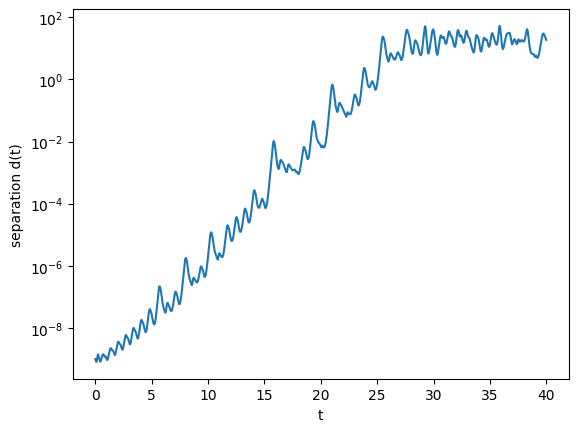

In [47]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="3d")
ax.plot(*traj_1, lw=0.5, label="IC 1")
ax.plot(*traj_2, lw=0.5, label="IC 2")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z"); ax.legend()

d = np.linalg.norm(traj_1 - traj_2, axis=0)   # shape (10000,)
plt.figure()
plt.semilogy(t_eval, d)                      # log-y reveals exponential growth
plt.xlabel("t"); plt.ylabel("separation d(t)")

In [48]:
N = 100
rng = np.random.default_rng(0)
basis = np.eye(3)
all_d = []
for _ in range(N):
    x0 = rng.uniform([-15, -15, 0], [15, 15, 30])
    er = basis[rng.integers(3)]
    a = solve_ivp(rhs, (0, 40), x0, t_eval=t_eval, rtol=1e-10, atol=1e-12).y
    b = solve_ivp(rhs, (0, 40), x0 + epsilon * er, t_eval=t_eval, rtol=1e-10, atol=1e-12).y
    all_d.append(np.linalg.norm(a - b, axis=0))

array([1.00000008e-09, 9.81375382e-10, 9.66794013e-10, ...,
       1.67207589e+01, 1.67765189e+01, 1.68331451e+01], shape=(10000,))

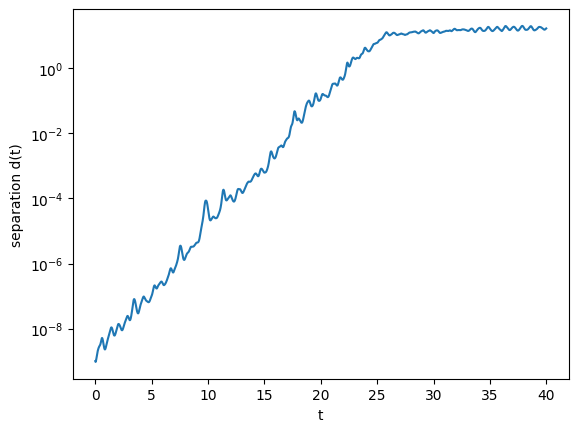

In [49]:
mean_d = np.mean(all_d, axis=0)
display(mean_d)

plt.figure()
plt.semilogy(t_eval, mean_d)                      # log-y reveals exponential growth
plt.xlabel("t"); plt.ylabel("separation d(t)")
ax.xaxis.set_major_locator(MultipleLocator(10))

In [50]:
mask = (t_eval > 0) & (t_eval < 25)
slope, _ = np.polyfit(t_eval[mask], np.log(mean_d[mask]), 1)
tau = 1 / slope
print(f"The calcuated Lyapunov time from the fit is: {tau:.3f}")

The calcuated Lyapunov time from the fit is: 1.108


## 2 Machine learning the dynamics of the Lorenz system

### Task 1

In [51]:
N = 100
t_eval = np.linspace(0., 4., 400)
ics = rng.uniform([-15, -15, 0], [15, 15, 30], size=(N, 3))
lorenz_traj = np.stack([
    solve_ivp(rhs, (0, 4.), ic, t_eval=t_eval, rtol=1e-9, atol=1e-9).y.T
    for ic in ics
])

/tmp/ipykernel_61438/330143211.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z"); ax.legend()


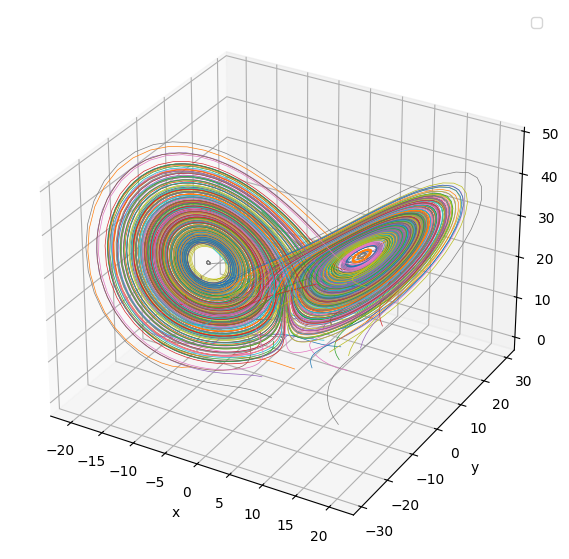

In [52]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="3d")
for traj in lorenz_traj:
    ax.plot(*traj.T, lw=0.5)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z"); ax.legend()

In [53]:
traj_train, traj_test = train_test_split(lorenz_traj, test_size=0.2, random_state=7)

### Task 2

In [54]:
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(traj_train.reshape(-1, 3))

def make_pairs(trajs):
    X = trajs[:, :-1].reshape(-1, 3)   # x(t_k)
    Y = trajs[:, 1:].reshape(-1, 3)    # x(t_{k+1})
    return scaler.transform(X), scaler.transform(Y)

X_train, y_train = make_pairs(traj_train)
X_test,  y_test  = make_pairs(traj_test)

### Task 3

In [55]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
np.random.seed(7)
torch.manual_seed(7)
print("Using device:", device)

Using device: cpu


In [56]:
# Taken from the given notebook
class History:
    def __init__(self):
        self.history = {"loss": [], "val_loss": []}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class FeedForwardNN(nn.Module):
    """One-step predictor: maps x(t_k) -> x(t_{k+1})."""
    def __init__(self, dim=1, hidden=20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim),   # no activation after the output
        )

    def forward(self, x):
        return self.net(x)


mlp_model = FeedForwardNN(dim=3, hidden=64).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

In [57]:
def make_loader(X, y, batch_size=256, shuffle=True):
    X_tensor = torch.as_tensor(X, dtype=torch.float32)
    y_tensor = torch.as_tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, optimizer, loss_fn, epochs, val_loader=None):
    hist = History()
    for epoch in range(epochs):
        model.train()
        train_loss, train_count = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.shape[0]
            train_count += xb.shape[0]
        train_loss /= train_count
        hist.history["loss"].append(train_loss)
        message = f"Epoch {epoch + 1}/{epochs} - loss: {train_loss:.6g}"

        if val_loader is not None:
            model.eval()
            val_loss, val_count = 0.0, 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += loss_fn(model(xb), yb).item() * xb.shape[0]
                    val_count += xb.shape[0]
            val_loss /= val_count
            hist.history["val_loss"].append(val_loss)
            message += f" - val_loss: {val_loss:.6g}"

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(message)
    return hist


train_loader = make_loader(X_train, y_train, batch_size=256, shuffle=True)
val_loader = make_loader(X_test, y_test, batch_size=256, shuffle=False)
hist = train_model(mlp_model, train_loader, optimizer, loss_fn, epochs=200, val_loader=val_loader)

Epoch 1/200 - loss: 0.013452 - val_loss: 0.000262831
Epoch 10/200 - loss: 1.85869e-05 - val_loss: 1.77655e-05
Epoch 20/200 - loss: 1.10181e-05 - val_loss: 9.33841e-06
Epoch 30/200 - loss: 7.42829e-06 - val_loss: 6.14057e-06
Epoch 40/200 - loss: 6.28763e-06 - val_loss: 4.68619e-06
Epoch 50/200 - loss: 6.02216e-06 - val_loss: 6.07611e-06
Epoch 60/200 - loss: 4.87643e-06 - val_loss: 2.53845e-06
Epoch 70/200 - loss: 2.99642e-06 - val_loss: 2.37764e-06
Epoch 80/200 - loss: 3.35334e-06 - val_loss: 7.01794e-06
Epoch 90/200 - loss: 2.80068e-06 - val_loss: 2.66463e-06
Epoch 100/200 - loss: 4.90581e-06 - val_loss: 1.15741e-06
Epoch 110/200 - loss: 2.7637e-06 - val_loss: 5.00908e-06
Epoch 120/200 - loss: 3.5908e-06 - val_loss: 6.29434e-06
Epoch 130/200 - loss: 2.87276e-06 - val_loss: 1.88488e-06
Epoch 140/200 - loss: 3.36056e-06 - val_loss: 1.09145e-06
Epoch 150/200 - loss: 3.58751e-06 - val_loss: 2.8789e-06
Epoch 160/200 - loss: 2.21041e-06 - val_loss: 1.67428e-06
Epoch 170/200 - loss: 2.71119e-

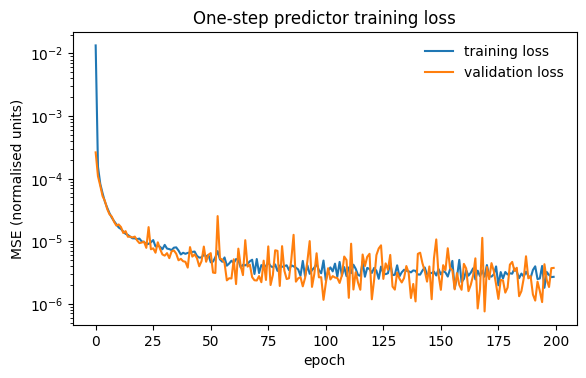

In [58]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogy(hist.history["loss"], label="training loss")
ax.semilogy(hist.history["val_loss"], label="validation loss")
ax.legend(frameon=False)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (normalised units)")
ax.set_title("One-step predictor training loss")
plt.show()

### Task 4

In [59]:
def rollout(model, x0, n_steps, sc=None):
    if sc is None:
        sc = scaler
    xs = np.zeros((n_steps + 1, 3)); xs[0] = x0
    model.eval()
    with torch.no_grad():
        for k in range(n_steps):
            xn   = sc.transform(xs[k:k+1])
            xn_t = torch.as_tensor(xn, dtype=torch.float32, device=device)
            pred = model(xn_t).cpu().numpy()
            xs[k+1] = sc.inverse_transform(pred)
    return xs

Text(0.5, 0, 't')

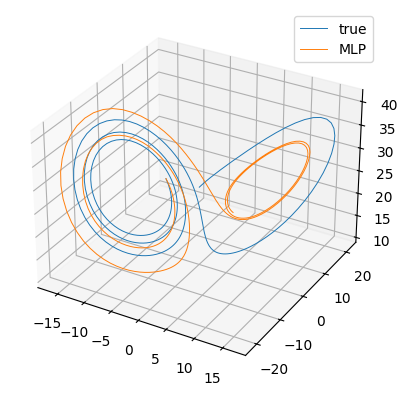

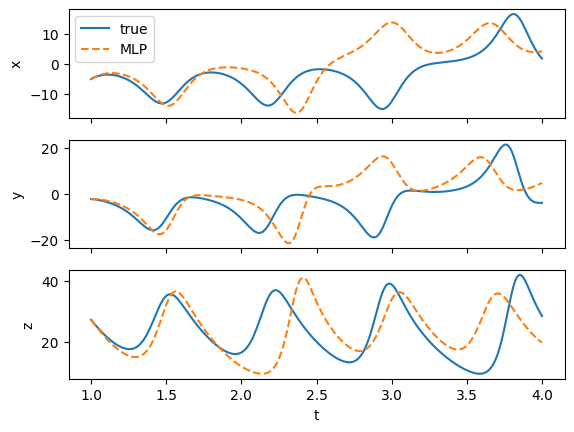

In [60]:
true_i  = traj_test[0]
start   = 100
n_steps = len(true_i) - 1 - start
pred_i  = rollout(mlp_model, true_i[start], n_steps)

fig = plt.figure(); ax = fig.add_subplot(projection="3d")
ax.plot(*true_i[start:].T, label="true", lw=0.7)
ax.plot(*pred_i.T,          label="MLP",  lw=0.7)
ax.legend()

# Per-component plot to see how long pointwise accuracy holds
tt = np.linspace(1, 4, n_steps + 1)
fig, axes = plt.subplots(3, 1, sharex=True)
for i, label in enumerate(["x","y","z"]):
    axes[i].plot(tt, true_i[start:, i], label="true")
    axes[i].plot(tt, pred_i[:, i],      label="MLP", ls="--")
    axes[i].set_ylabel(label)
axes[0].legend(); axes[-1].set_xlabel("t")

### Task 5

In [61]:
# Again using the functions provided in the example notebook
class NeuralLogistic(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3),
        )

        # Normalization buffers make optimization less sensitive to units.
        self.register_buffer("x_mean", torch.zeros(3))
        self.register_buffer("x_std", torch.ones(3))
        self.register_buffer("dxdt_std", torch.ones(3))

    def set_normalization(self, x_mean, x_std, dxdt_std):
        self.x_mean.copy_(x_mean)
        self.x_std.copy_(x_std)
        self.dxdt_std.copy_(dxdt_std)

    def forward(self, t, x):
        x_norm = (x - self.x_mean) / self.x_std
        return self.dxdt_std * self.net(x_norm)

In [62]:
def estimate_normalization(x_data):
    x_flat = x_data.reshape(-1, 3)
    x_mean = x_flat.mean(0)
    x_std = x_flat.std(0).clamp_min(1e-6)

    dxdt = (x_data[:, 1:] - x_data[:, :-1]) / dt
    dxdt_std = dxdt.reshape(-1, 3).std(0).clamp(min=0.2, max=3.0)
    return x_mean, x_std, dxdt_std

x_train_tensor = torch.as_tensor(traj_train, dtype=torch.float32, device=device)
dt = t_eval[1] - t_eval[0] 
model = NeuralLogistic(hidden_dim=32).to(device)
model.set_normalization(*estimate_normalization(x_train_tensor))

In [63]:
def sample_window_batch(x_data, batch_size=32, window_size=25):
    n_traj, n_time, _ = x_data.shape
    traj_idx = np.random.randint(0, n_traj, size=batch_size)
    starts = np.random.randint(0, n_time - window_size, size=batch_size)

    x0_batch = torch.stack([x_data[j, s] for j, s in zip(traj_idx, starts)])
    y_batch = torch.stack([x_data[j, s:s + window_size] for j, s in zip(traj_idx, starts)])
    return x0_batch, y_batch

W=  5  final loss 7.1819e-02
W= 10  final loss 1.1537e-01
W= 25  final loss 1.3674e+00
W= 50  final loss 2.3057e+00


Text(0, 0.5, 'loss')

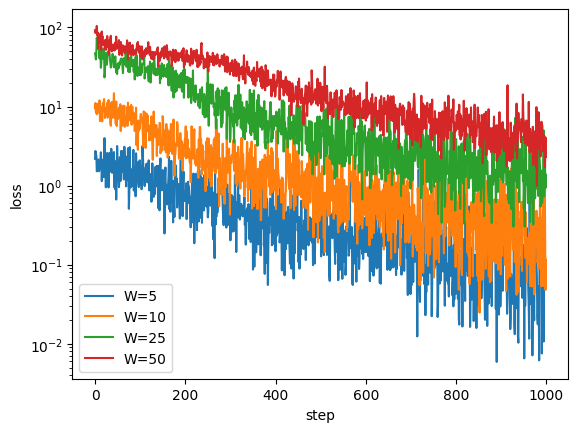

In [64]:
results = {}
for W in [5, 10, 25, 50]:
    m = NeuralLogistic(hidden_dim=64).to(device)
    m.set_normalization(*estimate_normalization(x_train_tensor))
    opt = torch.optim.Adam(m.parameters(), lr=3e-3)
    t_window = torch.arange(W, device=device).float() * dt

    losses = []
    for step in range(1, 1001):
        x0_b, y_b = sample_window_batch(x_train_tensor, window_size=W)
        pred   = odeint(m, x0_b, t_window, method="rk4")
        target = y_b.permute(1, 0, 2)
        loss   = nn.MSELoss()(pred, target)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 10.)
        opt.step()
        losses.append(float(loss.detach()))

    results[W] = {"model": m, "losses": losses}
    print(f"W={W:3d}  final loss {losses[-1]:.4e}")

# Compare final losses across window sizes
for W, r in results.items():
    plt.semilogy(r["losses"], label=f"W={W}")
plt.legend(); plt.xlabel("step"); plt.ylabel("loss")

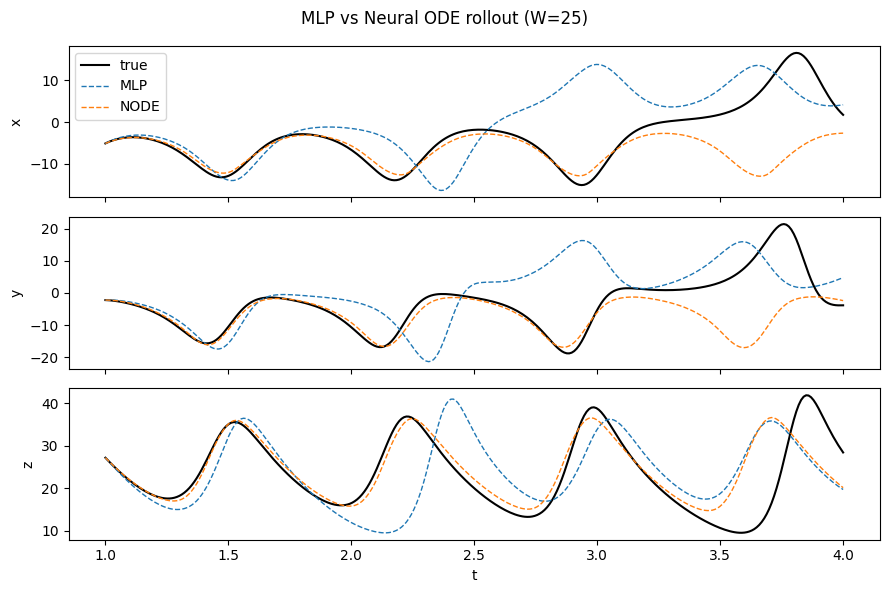

In [65]:
true_i = traj_test[0]
start = 100
n_pts = len(true_i) - start
tt = np.linspace(1, 4, n_pts)

# MLP rollout
pred_mlp = rollout(mlp_model, true_i[start], n_pts - 1)

# Neural ODE rollout
node_model = results[25]["model"]
node_model.eval()
x0_t  = torch.as_tensor(true_i[start], dtype=torch.float32, device=device).unsqueeze(0)
t_grid = torch.linspace(1, 4, n_pts, device=device)
with torch.no_grad():
    pred_node = odeint(node_model, x0_t, t_grid, method="dopri5")[:, 0].cpu().numpy()

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i, label in enumerate(["x", "y", "z"]):
    axes[i].plot(tt, true_i[start:, i], color="k",  lw=1.5, label="true")
    axes[i].plot(tt, pred_mlp[:, i],    color="C0", lw=1.0, ls="--", label="MLP")
    axes[i].plot(tt, pred_node[:, i],   color="C1", lw=1.0, ls="--", label="NODE")
    axes[i].set_ylabel(label)
axes[0].legend(); axes[-1].set_xlabel("t")
fig.suptitle("MLP vs Neural ODE rollout (W=25)")
plt.tight_layout()

### Task 6

In [66]:
rng = np.random.default_rng(1)
stored_noise = {}

for sigma in [0.0, 0.5, 2.0]:
    noisy_train = traj_train + sigma * rng.standard_normal(traj_train.shape)
    #noisy_test  = traj_test  + sigma * rng.standard_normal(traj_test.shape)
    noisy_train_tensor = torch.as_tensor(noisy_train, dtype=torch.float32, device=device)

    # Refit scaler on noisy training data
    scaler_n = MinMaxScaler(feature_range=(-1,1)).fit(noisy_train.reshape(-1,3))
    
    # Build pairs manually using scaler_n
    X_tr = scaler_n.transform(noisy_train[:, :-1].reshape(-1, 3))
    y_tr = scaler_n.transform(noisy_train[:, 1:].reshape(-1, 3))
    #X_te = scaler_n.transform(noisy_test[:, :-1].reshape(-1, 3))
    #y_te = scaler_n.transform(noisy_test[:, 1:].reshape(-1, 3))

    # Retrain MLP
    mlp_n = FeedForwardNN(dim=3, hidden=64).to(device)
    train_model(mlp_n, make_loader(X_tr, y_tr), 
                torch.optim.Adam(mlp_n.parameters(), lr=1e-3),
                nn.MSELoss(), epochs=200)
    
    # Retrain neural ODE
    node_noisy = NeuralLogistic(hidden_dim=64).to(device)
    node_noisy.set_normalization(*estimate_normalization(noisy_train_tensor))
    opt = torch.optim.Adam(node_noisy.parameters(), lr=3e-3)
    W = 25
    t_window = torch.arange(W, device=device).float() * dt

    for step in range(1, 1001):
        x0_b, y_b = sample_window_batch(noisy_train_tensor, window_size=W)
        pred   = odeint(node_noisy, x0_b, t_window, method="rk4")
        target = y_b.permute(1, 0, 2)
        loss   = nn.MSELoss()(pred, target)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(node_noisy.parameters(), 10.)
        opt.step()


    stored_noise[sigma] = {"mlp": mlp_n, "node": node_noisy, "scaler": scaler_n}
    print(f"sigma={sigma} done")

Epoch 1/200 - loss: 0.0129988
Epoch 10/200 - loss: 1.17085e-05
Epoch 20/200 - loss: 6.43492e-06
Epoch 30/200 - loss: 5.31911e-06
Epoch 40/200 - loss: 4.76686e-06
Epoch 50/200 - loss: 5.88198e-06
Epoch 60/200 - loss: 4.89793e-06
Epoch 70/200 - loss: 4.4792e-06
Epoch 80/200 - loss: 4.98697e-06
Epoch 90/200 - loss: 4.4871e-06
Epoch 100/200 - loss: 3.55638e-06
Epoch 110/200 - loss: 3.20939e-06
Epoch 120/200 - loss: 3.46282e-06
Epoch 130/200 - loss: 2.82634e-06
Epoch 140/200 - loss: 3.30353e-06
Epoch 150/200 - loss: 2.51829e-06
Epoch 160/200 - loss: 3.31359e-06
Epoch 170/200 - loss: 3.30391e-06
Epoch 180/200 - loss: 2.69398e-06
Epoch 190/200 - loss: 3.12602e-06
Epoch 200/200 - loss: 3.46838e-06
sigma=0.0 done
Epoch 1/200 - loss: 0.0108986
Epoch 10/200 - loss: 0.000767843
Epoch 20/200 - loss: 0.000760611
Epoch 30/200 - loss: 0.000758673
Epoch 40/200 - loss: 0.000746602
Epoch 50/200 - loss: 0.000738382
Epoch 60/200 - loss: 0.00072455
Epoch 70/200 - loss: 0.000719084
Epoch 80/200 - loss: 0.000

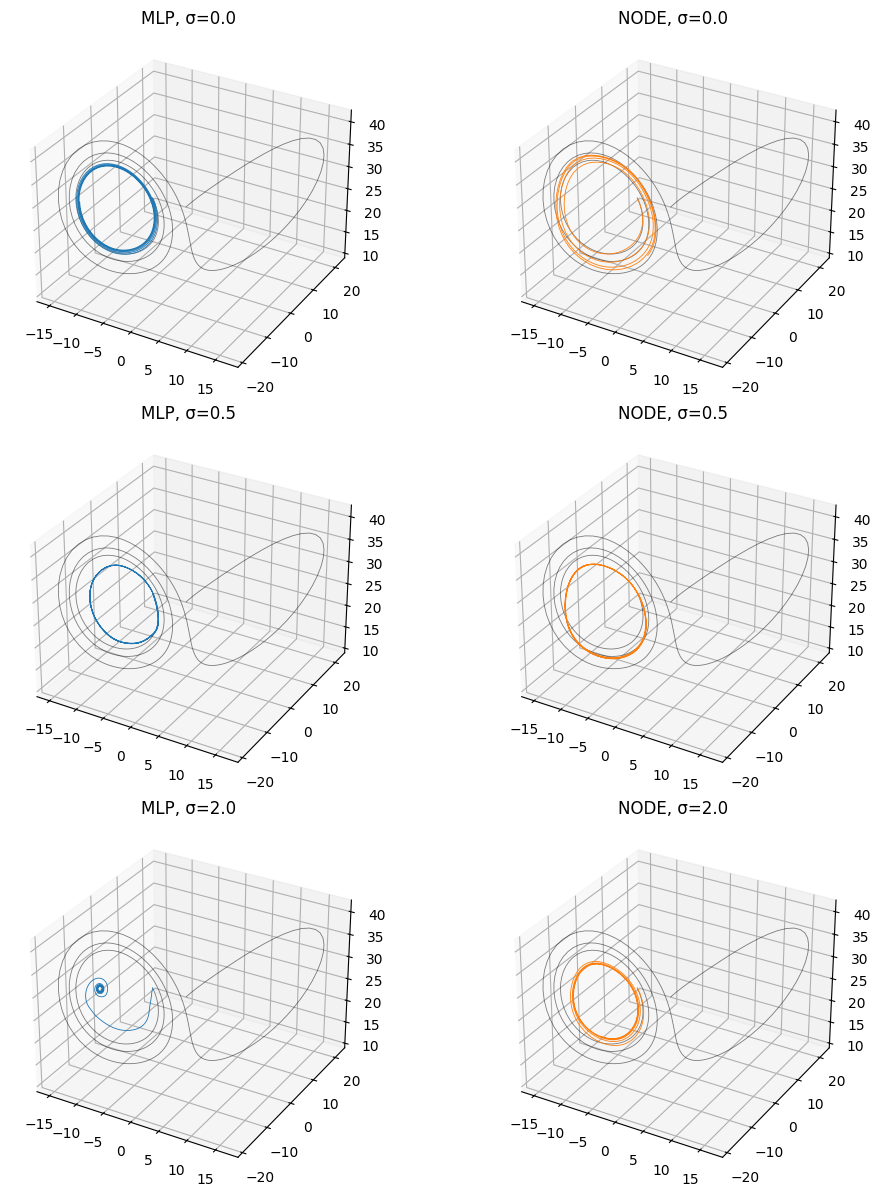

In [67]:
true_i = traj_test[0]; start = 100
n_pts  = len(true_i) - start
t_grid = torch.linspace(1, 4, n_pts, device=device)

fig = plt.figure(figsize=(11, 4 * len([0.0, 0.5, 2.0])))
for row, sigma in enumerate([0.0, 0.5, 2.0]):
    s = stored_noise[sigma]

    pred_mlp = rollout(s["mlp"], true_i[start], n_pts - 1, sc=s["scaler"])   # uses noisy scaler

    s["node"].eval()
    x0_t = torch.as_tensor(true_i[start], dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        pred_node = odeint(s["node"], x0_t, t_grid, method="dopri5")[:, 0].cpu().numpy()

    for col, (pred, name, c) in enumerate([(pred_mlp, "MLP", "C0"), (pred_node, "NODE", "C1")]):
        ax = fig.add_subplot(len([0.0, 0.5, 2.0]), 2, row * 2 + col + 1, projection="3d")
        ax.plot(*true_i[start:].T, color="k", lw=0.6, alpha=0.5)
        ax.plot(*pred.T, color=c, lw=0.6)
        ax.set_title(f"{name}, σ={sigma}")
plt.tight_layout()